### Imports

Required libraries for data analysis and visualization were imported.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

Loan data was loaded from processed parquet file.

In [4]:
# Data loading
loans = pd.read_parquet('../data/processed/parquet/accepted.parquet')

The first 5 rows of the loan dataset were displayed to confirm the structure.

In [5]:
# Checking the data 
loans.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,mort_acc,pub_rec_bankruptcies,credit_history,acc_to_history_ratio,debt_burden_ratio,is_default,is_high_dti,is_high_util,is_high_risk_grade,is_unverified
0,32000.0,60,10.49,687.65,B,B3,Public Service,10,MORTGAGE,120000.0,...,2.0,0.0,33.34,1.26,0.07,0,0,0,0,0
1,9600.0,36,12.99,323.42,C,C1,Teacher,10,RENT,21900.0,...,0.0,1.0,13.08,1.53,0.18,0,0,0,0,0
2,4000.0,36,6.68,122.93,A,A3,System Analyst,4,MORTGAGE,83000.0,...,2.0,0.0,11.58,2.16,0.02,0,0,0,0,1
3,6025.0,36,10.91,197.00,B,B4,Admin assistant,10,RENT,52000.0,...,0.0,0.0,12.50,2.00,0.05,0,0,0,0,1
4,25000.0,60,26.30,752.96,E,E5,Coordinator,10,OWN,65000.0,...,0.0,0.0,18.59,1.78,0.14,0,1,0,1,0


### Plot Style Settings

Set global plotting style to seaborn and defined default figure size.

In [6]:
# Plot settings
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = [12, 6]

### Helper Functions

The `calculate_default_rate` function calculates the default rate as a percentage:
- Input: DataFrame and optional grouping column
- For grouped analysis: returns default rates for each group
- For ungrouped analysis: returns overall default rate
- Default rates were calculates as mean of `is_default` multiplied by 100

In [2]:
# Calculates default rate, optionally by group
def calculate_default_rate(data, group_col=None):
    if group_col:
        return data.groupby(group_col)['is_default'].mean() * 100
    return data['is_default'].mean() * 100

The `create_subplot_figure` function created standardized matplotlib subplots:
- Inputs: number of rows, columns, and figure dimensions
- Default configuration: 1x2 subplot with 12x5 figure size
- Returns: figure and axes objects for further customization
- Provides consistent styling across visualizations

In [13]:
# Creates figure with standard styling
def create_subplot_figure(nrows=1, ncols=2, width=12, height=5):
    fig, axes = plt.subplots(nrows, ncols, figsize=(width, height))
    return fig, axes

### Portfolio Summary Statistics

Created basic portfolio metrics:
- Total loan count
- Total portfolio value
- Average loan amount
- Overall default rate

In [7]:
# Portfolio overview
print("Portfolio Overview:")
print(f"Total number of loans: {len(loans):,}")
print(f"Total portfolio value: ${loans['loan_amnt'].sum():,.2f}")
print(f"Average loan amount: ${loans['loan_amnt'].mean():,.2f}")
print(f"Default rate: {calculate_default_rate(loans):.2f}%")

Portfolio Overview:
Total number of loans: 2,000,000
Total portfolio value: $30,096,034,850.00
Average loan amount: $15,048.02
Default rate: 13.05%


### Grade Analysis

Generated two plots:
1. Distribution of loans across grades
2. Default rates by grade

This visualization shows the relationship between loan grades and default risk.

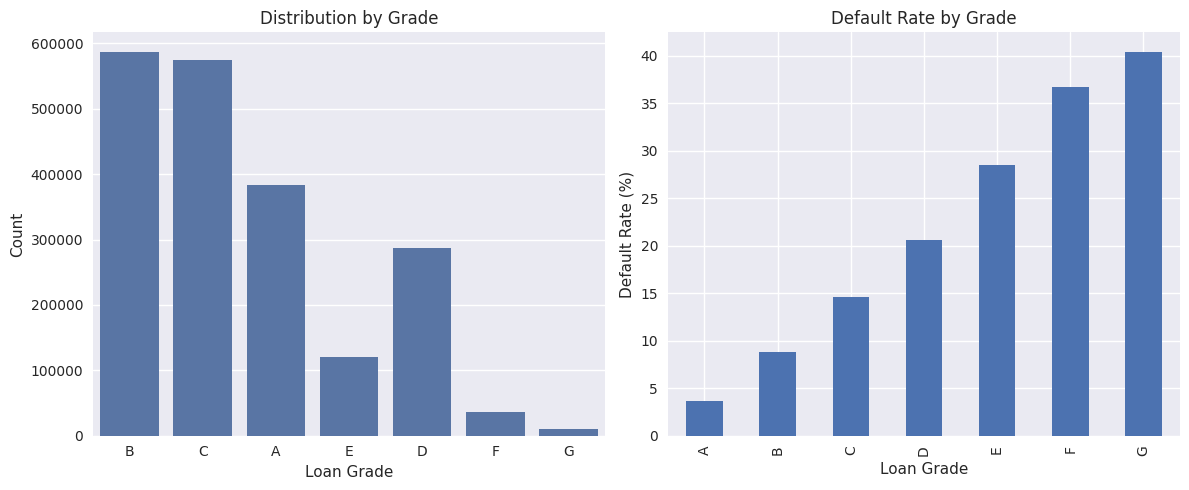

In [ ]:
# Risk grade distribution and performance
fig, (ax1, ax2) = create_subplot_figure()

# Grade distribution
sns.countplot(data=loans, x='grade', ax=ax1)
ax1.set_title('Distribution by Grade')
ax1.set_xlabel('Loan Grade')
ax1.set_ylabel('Count')

# Default rate by grade
default_by_grade = calculate_default_rate(loans, 'grade')
default_by_grade.plot(kind='bar', ax=ax2)
ax2.set_title('Default Rate by Grade')
ax2.set_xlabel('Loan Grade')
ax2.set_ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

### Risk Indicator Analysis

Analyzed four key risk indicators:
- High DTI (Debt-to-Income ratio)
- High Utilization
- High Risk Grade
- Unverified Income

Calculates prevalence and default rates for each indicator.

In [9]:
# Key risk indicators
risk_indicators = {
    'High DTI (>30%)': 'is_high_dti',
    'High Util (>60%)': 'is_high_util',
    'High Risk Grade': 'is_high_risk_grade',
    'Unverified Income': 'is_unverified'
}

# Calculates and displays risk indicator stats
print("\nRisk Indicator Prevalence and Default Rates:")
for name, indicator in risk_indicators.items():
    prevalence = loans[indicator].mean() * 100
    default_rate = calculate_default_rate(loans[loans[indicator] == 1])
    print(f"\n{name}:")
    print(f"Prevalence: {prevalence:.1f}%")
    print(f"Default Rate: {default_rate:.1f}%")


Risk Indicator Prevalence and Default Rates:

High DTI (>30%):
Prevalence: 10.9%
Default Rate: 16.7%

High Util (>60%):
Prevalence: 36.6%
Default Rate: 15.1%

High Risk Grade:
Prevalence: 8.4%
Default Rate: 31.1%

Unverified Income:
Prevalence: 33.0%
Default Rate: 9.0%


### Credit Profile Distribution

Generated two histograms:
- Credit history length distribution
- Account velocity (accounts per year) distribution

These metrics help understand borrowers' credit experience.

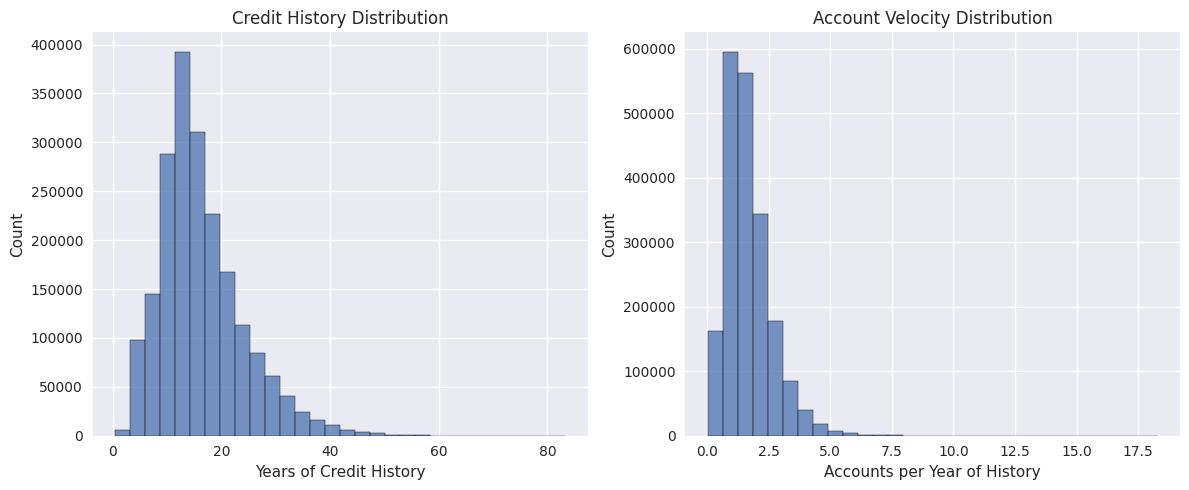

In [ ]:
# Credit history and performance
fig, (ax1, ax2) = create_subplot_figure()

# Credit history distribution
sns.histplot(data=loans, x='credit_history', bins=30, ax=ax1)
ax1.set_title('Credit History Distribution')
ax1.set_xlabel('Years of Credit History')

# Account velocity distribution
sns.histplot(data=loans, x='acc_to_history_ratio', bins=30, ax=ax2)
ax2.set_title('Account Velocity Distribution')
ax2.set_xlabel('Accounts per Year of History')
plt.tight_layout()
plt.show()

### Key Loan Characteristics

Created a 2x2 grid of plots showing distributions of:
1. Loan amounts
2. Interest rates by grade
3. Loan term distribution
4. Debt burden ratio

These visualizations provide comprehensive view of loan characteristics.

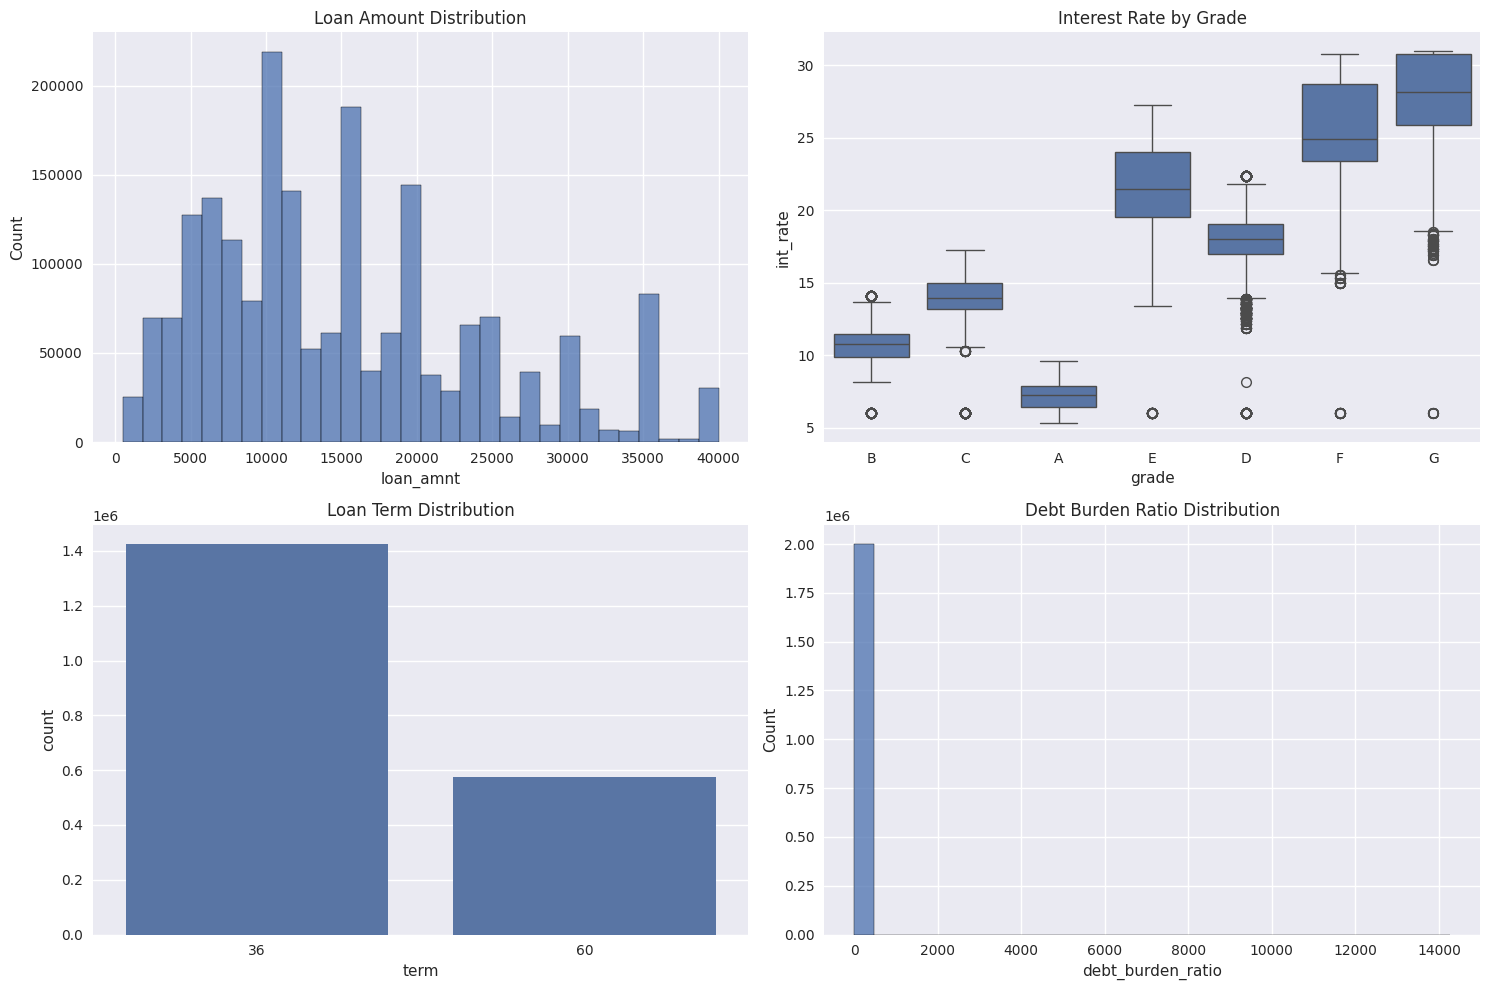

In [ ]:
# Loan characteristics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loan amount distribution
sns.histplot(data=loans, x='loan_amnt', bins=30, ax=axes[0,0])
axes[0,0].set_title('Loan Amount Distribution')

# Interest rate by grade
sns.boxplot(data=loans, x='grade', y='int_rate', ax=axes[0,1])
axes[0,1].set_title('Interest Rate by Grade')

# Term distribution
sns.countplot(data=loans, x='term', ax=axes[1,0])
axes[1,0].set_title('Loan Term Distribution')

# Debt burden ratio distribution
sns.histplot(data=loans, x='debt_burden_ratio', bins=30, ax=axes[1,1])
axes[1,1].set_title('Debt Burden Ratio Distribution')
plt.tight_layout()
plt.show()

### Statistical Summary

Generated summary statistics for key numerical variables:
- Loan amount
- Interest rate
- DTI
- Credit history
- Revolving utilization

In [12]:
# Summary statistics
print("\nKey Metrics Summary:")
summary_stats = loans[['loan_amnt', 'int_rate', 'dti', 'credit_history', 
                      'revol_util']].describe()
print(summary_stats.round(2))


Key Metrics Summary:
        loan_amnt    int_rate         dti  credit_history  revol_util
count  2000000.00  2000000.00  2000000.00      1999948.00  2000000.00
mean     15048.02       13.09       18.48           16.40       50.31
std       9189.92        4.83        8.83            7.68       24.65
min        500.00        5.31       -1.00            0.50        0.00
25%       8000.00        9.49       11.90           11.25       31.50
50%      12925.00       12.62       17.84           14.83       50.30
75%      20000.00       15.99       24.49           20.25       69.30
max      40000.00       30.99       42.73           83.25       98.10


### Conclusion

The exploratory data analysis reveals several key insights about the loan portfolio:

**Portfolio Composition and Performance**
- The portfolio consists of 2M loans totaling $30.1B, with an average loan size of $15K
- The overall default rate is 13.05%, indicating significant credit risk exposure
- Loan amounts show wide variation ($500-$40K) with median at $12.9K

**Risk Indicators**
- High Risk Grade loans (8.4% of portfolio) show the highest default rate at 31.1%
- High DTI borrowers (10.9% of portfolio) default at 16.7%, above portfolio average
- High Utilization is the most prevalent risk factor (36.6%) with 15.1% default rate
- Surprisingly, unverified income loans (33% of portfolio) show lower default rates (9%)

**Credit Profile Characteristics**
- Interest rates range from 5.31% to 30.99%, with mean of 13.09%
- Borrowers have substantial credit history (median 14.8 years)
- Revolving utilization is moderately high (median 50.3%)
- DTI ratios are generally manageable (median 17.84%)

These findings suggest that grade assignment effectively captures default risk, while traditional risk indicators like DTI and utilization provide additional predictive value. The lower default rate for unverified income loans warrants further investigation into the verification process effectiveness.